# **Step1. 상품 리뷰 감성 분류**

**미션 : 리뷰마다 긍/부정 감성분석하기**
1) 목표 : 리뷰를 긍, 부정으로 분류하는 모델 생성
사전학습 모델을 파인 튜닝하여 모델 성능 높이기
2) 절차
    * 데이터 전처리
        - 긍/부정 분류를 위한 데이터셋 구성
        - 데이터 불균형 문제 해결하기
    * 사전학습 모델 파인 튜닝 : klue/bert-base 사용 권장
3) 최소 4가지 이상의 실험을 구성하고 수행하고 성능 비교
    * 학습 + 검증 데이터 : 10만 건 중 일부를 샘플링해서 수행.
    * 모델링 : 일반 파인튜닝, LoRA 파인튜닝 적용
    * 하이퍼파라미터 조정


## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [1]:
!pip install datasets peft accelerate -q

* 설치 후 세션 다시 시작

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')

* 함수 생성

In [3]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(list(val_ds['text']), return_tensors="pt", padding=True,
                       truncation=True, max_length=128    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [4]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


### (2) GPU 설정
* GPU 사용을 위한 설정

In [5]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비① : 데이터 구조 만들기
* 아래와 같은 형태로 데이터 셋을 준비합니다.
    * 하나의 리뷰 문장에 하나의 긍/부정 값 지정
    * 리뷰별 label의 평균 값 >= 0.5 ➔ 긍정(1)

* 데이터 불균형을 확인하고 조치합니다.

### (1) 데이터 불러오기
* 제공 받은 'data.csv' 파일을 불러 옵니다.

In [6]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [7]:
data = pd.read_csv('data.csv')
data.head()

,text,aspect,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,포장,1
1,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,품질,1
2,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,보습,1
3,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,포장,0
4,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,기타,1


### (2) 데이터 구조 만들기

* 다음과 같은 형태로 리뷰별 데이터 구조를 만듭니다.

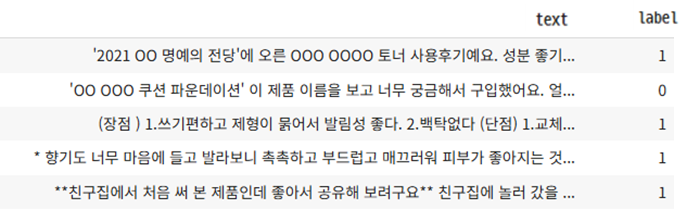

In [8]:
data0 = data.groupby('text', as_index=False)['label'].mean()
data0['label'] = np.where(data0['label']>=0.5, 1, 0)
data0.head()

,text,label
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,1
1,'2022 대한민국소비자대상' 수상을 축하하며 오랜만에 써 본 OO OOO 로션 사...,1
2,'OO OOO 쿠션 파운데이션' 이 제품 이름을 보고 너무 궁금해서 구입했어요. 얼...,0
3,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,1
4,* 향기도 너무 마음에 들고 발라보니 촉촉하고 부드럽고 매끄러워 피부가 좋아지는 것...,1


### (3) 데이터 불균형 해결하기

* label의 분포 확인하기 : 막대그래프로

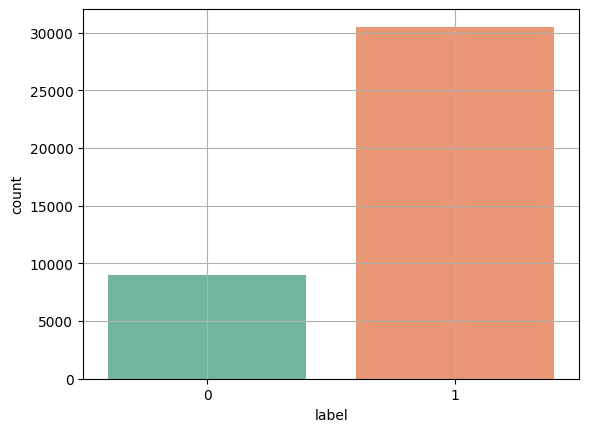

In [9]:
sns.countplot(x='label', data = data0, palette='Set2')
plt.grid()
plt.show()

* label이 0과 1인 인 경우 각각 샘플링 2000건씩
    * 더 많이 할 수도 있지만 학습 시간을 고려


In [10]:
# 데이터 샘플링
temp1 = data0.loc[data0['label']==0].sample(2000, random_state = 100)
temp2 = data0.loc[data0['label']==1].sample(2000, random_state = 100)

data1 = pd.concat([temp1, temp2])
data1.reset_index(drop=True, inplace=True)

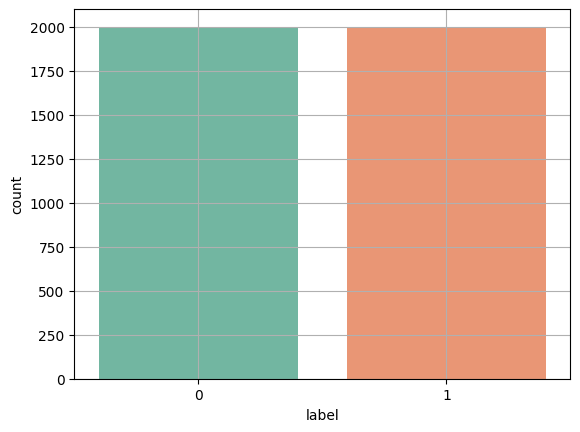

In [11]:
# 데이터 분포 다시 확인
sns.countplot(x='label', data = data1, palette='Set2')
plt.grid()
plt.show()

## 3.데이터 준비② : 데이터 전처리

### (1) Dataset 만들기 : train, val
* train_test_split 함수 이용

In [12]:
train, val = train_test_split(data1, test_size=0.1, random_state=100)

* 텐서 데이터셋 만들기

In [13]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [14]:
train_ts[:3]

{'text': ['언제나 사용하는 스킨브레이서 제품입니다. 요즘은 멘톨이 시원하게 들어간 제품이 거의 없고 이상한 제품만 나와서 이 제품을 구매하게 되었습니다. 가격도 저렴해서 좋은 것 같습니다. 바르고 나면 쿨링감이 있어서 좋고 금요일에 주문했는데 토요일에 도착하는 빠른 배송이라 좋네요.',
  '저자극이라 해서 브라운구매해 염색 했는데 발색이 브라운이아니라 블랙이던데요 그리고 너무가러워 ㅈ병원갔다왔네요 남은거는 아는형님쓰보라고드렸으요',
  '탈모에 좋은지는 모르겠지만 세정력은 무난하니 좋아서 자주 사용해요.'],
 'label': [1, 0, 1],
 '__index_level_0__': [2079, 995, 2154]}

### (2) 토크나이징
* 모델 : "klue/bert-base"

In [15]:
# 모델과 토크나이저 불러오기
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [16]:
# 토큰화 함수 생성 및 작업
def preprocess_function(data):
    return tokenizer(data['text'], truncation=True, padding=True)

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [17]:
train_ts[0]

{'text': '언제나 사용하는 스킨브레이서 제품입니다. 요즘은 멘톨이 시원하게 들어간 제품이 거의 없고 이상한 제품만 나와서 이 제품을 구매하게 되었습니다. 가격도 저렴해서 좋은 것 같습니다. 바르고 나면 쿨링감이 있어서 좋고 금요일에 주문했는데 토요일에 도착하는 빠른 배송이라 좋네요.',
 'label': 1,
 '__index_level_0__': 2079,
 'input_ids': [2,
  5641,
  3704,
  2205,
  2259,
  9497,
  2645,
  3930,
  2112,
  3808,
  12190,
  18,
  4442,
  2073,
  1067,
  2777,
  2052,
  6005,
  2205,
  2318,
  6510,
  3808,
  2052,
  4167,
  1415,
  2088,
  3658,
  2470,
  3808,
  2154,
  8678,
  1504,
  3808,
  2069,
  4625,
  2205,
  2318,
  859,
  2359,
  2219,
  3606,
  18,
  3852,
  2119,
  6206,
  6396,
  1560,
  2073,
  575,
  555,
  2219,
  3606,
  18,
  5957,
  2088,
  717,
  2460,
  26844,
  2434,
  2052,
  1513,
  2051,
  2112,
  1560,
  2088,
  9893,
  2170,
  4867,
  2371,
  13964,
  8414,
  2170,
  5082,
  2205,
  2259,
  5562,
  9488,
  2052,
  2181,
  1560,
  2203,
  2182,
  18,
  3,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,

## 4.Fine-Tuning ①
* 일반 파인 튜닝 수행

### (1) 사전학습 모델 준비

In [18]:
# 모델 로드
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

In [19]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 3,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

In [20]:
# Trainer 설정
trainer = Trainer(
    model=base_model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

### (3) 학습

In [21]:
# 모델 학습
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.187600,0.186024
2,0.104500,0.223213
3,0.017100,0.262667


TrainOutput(global_step=339, training_loss=0.13382094105084738, metrics={'train_runtime': 702.3715, 'train_samples_per_second': 15.376, 'train_steps_per_second': 0.483, 'total_flos': 1997999576640000.0, 'train_loss': 0.13382094105084738, 'epoch': 3.0})

### (4) 모델 검증평가

In [22]:
pred, prob = evaluate(val_ts, base_model, device, tokenizer)

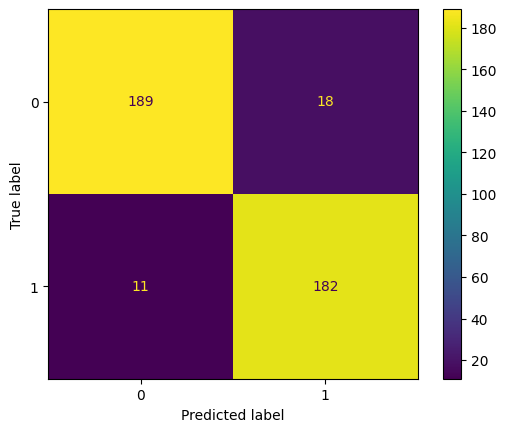

0.9275
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       207
           1       0.91      0.94      0.93       193

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred))
disp.plot()
plt.show()
print(accuracy_score(val_ts['label'], pred))
print(classification_report(val_ts['label'], pred))

## 5.Fine-Tuning②
* LoRA(Low-Rank Adaptation)

### (1) 사전학습 모델 준비
* 위에서 적용한 내용

In [24]:
# 사전 학습된 모델 로드 (전체 파라미터는 그대로)
num_labels = 2
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) LoRA 구성

In [25]:
# LoRA 구성 정의
lora_config = LoraConfig(
    r=8,                         # 랭크
    lora_alpha=16,              # scaling factor
    target_modules=["query", "value"],  # LoRA 적용 대상
    lora_dropout=0.05,
    bias="none",                # bias 조정 없음
    task_type=TaskType.SEQ_CLS # 시퀀스 분류 태스크
)

# LoRA 적용 (일부 레이어만 학습)
model2 = get_peft_model(model, lora_config)

### (3) 학습

In [26]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-4,               # LoRA는 조금 큰 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 3,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

# Trainer 설정 (compute_metrics, callbacks 등 필요 시 추가)
trainer = Trainer(
    model=model2,
    args=training_args,
    train_dataset=train_ts,
    eval_dataset=val_ts,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [27]:
# 학습 시작
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.218900,0.234270


Epoch,Training Loss,Validation Loss
1,0.218900,0.234270
2,0.179300,0.218682
3,0.150100,0.217315


TrainOutput(global_step=339, training_loss=0.22169216227742422, metrics={'train_runtime': 520.6933, 'train_samples_per_second': 20.742, 'train_steps_per_second': 0.651, 'total_flos': 2004915162240000.0, 'train_loss': 0.22169216227742422, 'epoch': 3.0})

### (4) 모델 검증평가

In [28]:
pred, prob = evaluate(val_ts, model2, device, tokenizer)

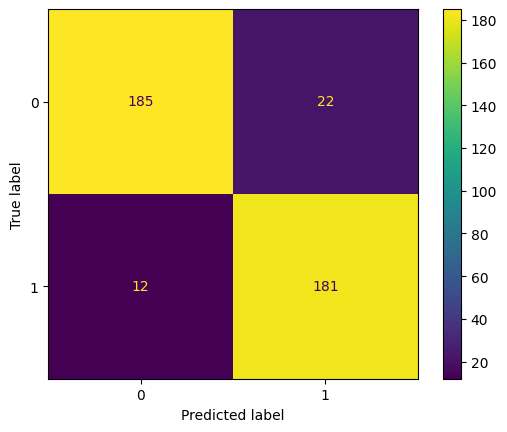

              precision    recall  f1-score   support

           0       0.94      0.89      0.92       207
           1       0.89      0.94      0.91       193

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.91       400
weighted avg       0.92      0.92      0.92       400



In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred))
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred))